# Credit Shield: Identifying and Mitigating Loan Default Risk

**Problem Statement**: Financial institutions face increasing loan defaults, leading to revenue loss and higher risk exposure. This project aims to analyze customer demographics, transaction behavior, and credit patterns to identify key factors driving loan defaults, segment high-risk customers, and recommend strategies to reduce default rates and improve risk management.

---


## 1. Load Raw CSV
Loading fresh from `data/raw/` to ensure we do not depend on notebook 01's memory.

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

raw_path = Path('../data/raw/UCI_Credit_Card_raw.csv')
df = pd.read_csv(raw_path)
print(f'Initial shape: {df.shape}')

Initial shape: (30000, 25)


## 2. Drop ID Column
**Why:** ID is a row identifier. If left in, correlation analysis will try to find a relationship between a customer's ID number and their default status, which is meaningless noise.

In [15]:
df = df.drop('ID', axis=1)
print(f'Shape after dropping ID: {df.shape}')

Shape after dropping ID: (30000, 24)


## 3. Rename Target Column
**Why:** Dots in column names break Python's dot notation access (`df.default.payment.next.month` would crash). `df.default_status` works cleanly. Professional codebases avoid dots in column names.

In [16]:
df = df.rename(columns={'default.payment.next.month': 'default_status'})
print('Columns renamed successfully.')

Columns renamed successfully.


## 4. Impute Missing Values in Categorical Columns
**Why Mode and not Mean or Median:**
- **Mean**: `EDUCATION` and `MARRIAGE` values are labels, not quantities. The mean of labels is mathematically nonsensical.
- **Median**: The middle value of a label set means nothing.
- **Mode**: The most frequently occurring valid category. For nominal variables, this is the only statistically defensible imputation.

We impute missing values (NaN) with the mode for both `EDUCATION` and `MARRIAGE`.

In [17]:
edu_mode = df['EDUCATION'].mode()[0]
mar_mode = df['MARRIAGE'].mode()[0]

print(f'Mode for EDUCATION: {edu_mode}')
print(f'Mode for MARRIAGE: {mar_mode}')

df['EDUCATION'] = df['EDUCATION'].fillna(edu_mode)
df['MARRIAGE'] = df['MARRIAGE'].fillna(mar_mode)

print('\nNull values after imputation:')
print(df[['EDUCATION', 'MARRIAGE']].isnull().sum())

Mode for EDUCATION: 2.0
Mode for MARRIAGE: 2.0

Null values after imputation:
EDUCATION    0
MARRIAGE     0
dtype: int64


## 5. PAY Columns: Recode -2 to -1
**Why NOT convert to NaN:**
PAY columns are behavioral data recording what a customer actually did. Value `-2` means 'no consumption that month' (no balance, no payment due, no delay). This is closest in meaning to `-1` (paid duly).
Converting to NaN would lose 6 months of behavioral history, making `avg_delay` and `max_delay` features unreliable. The behavioral signal is too valuable to throw away.

In [18]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for col in pay_cols:
    df[col] = df[col].replace(-2, -1)
print('Recoded -2 to -1 for all PAY columns.')

Recoded -2 to -1 for all PAY columns.


## 6. BILL_AMT: Document Negatives
**Why keep them:** Negative bill amount means the customer's payments exceeded their balance (the bank owes them money). This is a real financial state (credit balance). Removing these rows would silently delete well-behaved customers from the analysis, biasing results toward risky customers. No transformation is needed.

In [19]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
df[bill_cols].min()
print('\nObservation: Negative values exist, indicating credit balances. They are kept as they represent valid financial states.')


Observation: Negative values exist, indicating credit balances. They are kept as they represent valid financial states.


## 7. LIMIT_BAL and AGE Integrity Check
Verifying that there are no zero or negative credit limits, and that the age range is sensible (e.g., 21-79). No transformations expected.

In [20]:
df[['LIMIT_BAL', 'AGE']].agg(['min', 'max'])
print('\nObservation: Credit limits are strictly positive, and ages fall within a sensible adult range.')


Observation: Credit limits are strictly positive, and ages fall within a sensible adult range.


## 8. Outlier Detection and Handling
**Why:** Extreme credit limits or bill amounts can heavily skew statistical models and visualizations. We use the IQR method to identify and remove these extreme cases to prevent analytical skew.

OUTLIER AUDIT REPORT (IQR Method) — No rows removed
LIMIT_BAL    | Lower:   -235,000 | Upper:    525,000 | Outliers:   167 (0.56%)
BILL_AMT1    | Lower:    -91,740 | Upper:    162,389 | Outliers:  2400 (8.00%)
PAY_AMT1     | Lower:     -5,009 | Upper:     11,015 | Outliers:  2745 (9.15%)

Total rows retained: 30,000 (No rows dropped)


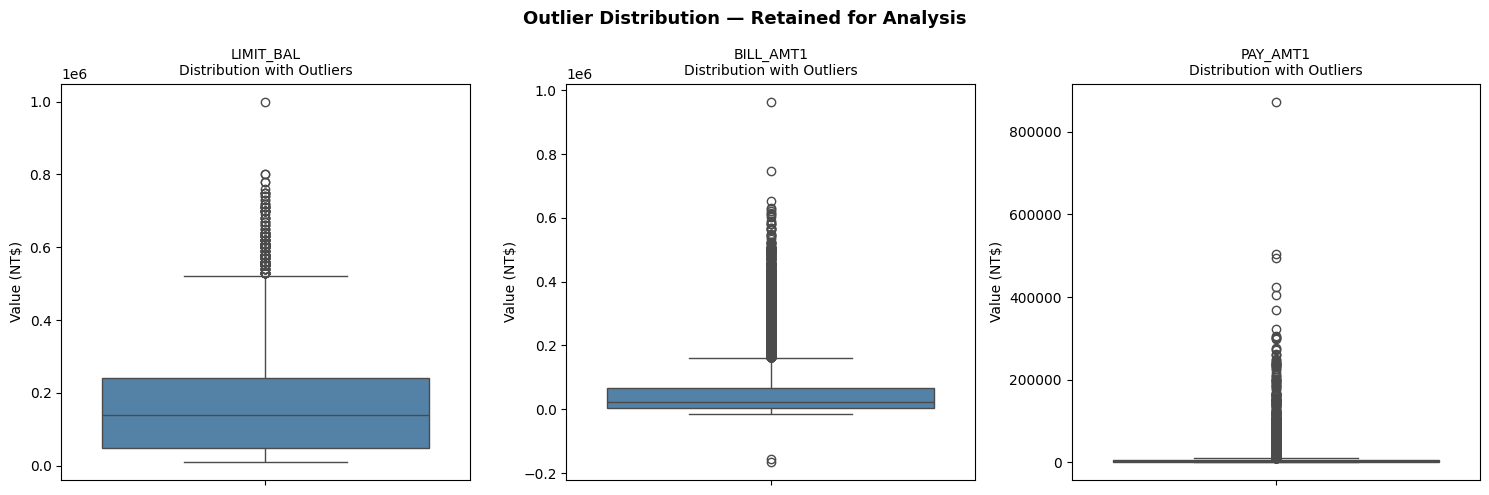


Observation:
Outliers are present in LIMIT_BAL, BILL_AMT1, and PAY_AMT1 as expected
for real-world financial data. These extreme values represent genuine
high-value customer profiles and are retained in the dataset. Their
presence will be acknowledged as a limitation in the final report.



In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Outlier Observation using IQR ──────────────────────────────
# Decision: Outliers are IDENTIFIED but NOT removed.
# Rationale: Extreme values in LIMIT_BAL, BILL_AMT1, and PAY_AMT1
# represent high-credit-limit and high-bill customers — valid financial
# profiles. Removing them would introduce selection bias by excluding
# the highest and lowest financial capacity segments from default risk analysis.

cols_to_check = ['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1']

print("=" * 60)
print("OUTLIER AUDIT REPORT (IQR Method) — No rows removed")
print("=" * 60)

for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_pct = (outlier_count / len(df)) * 100
    print(f"{col:12s} | Lower: {lower_bound:>10,.0f} | Upper: {upper_bound:>10,.0f} | Outliers: {outlier_count:>5} ({outlier_pct:.2f}%)")

print(f"\nTotal rows retained: {len(df):,} (No rows dropped)")
print("=" * 60)

# Visualise distribution with outliers retained
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cols_to_check):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col}\nDistribution with Outliers', fontsize=10)
    axes[i].set_ylabel('Value (NT$)')

plt.suptitle('Outlier Distribution — Retained for Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Observation:
Outliers are present in LIMIT_BAL, BILL_AMT1, and PAY_AMT1 as expected
for real-world financial data. These extreme values represent genuine
high-value customer profiles and are retained in the dataset. Their
presence will be acknowledged as a limitation in the final report.
""")

## 9. Feature Engineering: The 4 Derived Columns
Creating new derived features to strengthen the analysis.

- **Feature 1: utilization_ratio**: Measures how much of the credit limit is consumed (`BILL_AMT1 / LIMIT_BAL`). Handled division by zero by filling with 0.
- **Feature 2: avg_delay**: Average payment behavior across all 6 months. Patterns predict default better than anomalies.
- **Feature 3: max_delay**: The single worst month of payment behavior. Captures the worst-case behavior floor.
- **Feature 4: risk_tier**: Rule-based segmentation to classify customers into High, Medium, or Low risk. Explainable to stakeholders without a black-box machine learning model.

In [22]:
# Feature 1: utilization_ratio
df['utilization_ratio'] = np.where(df['LIMIT_BAL'] == 0, 0, df['BILL_AMT1'] / df['LIMIT_BAL'])
# Optional: cap at 1.0, though we leave it uncapped here to reflect extreme but valid debt.

# Feature 2: avg_delay
df['avg_delay'] = df[pay_cols].mean(axis=1)

# Feature 3: max_delay
df['max_delay'] = df[pay_cols].max(axis=1)

# Feature 4: risk_tier
conditions = [
    (df['max_delay'] >= 2) & (df['utilization_ratio'] > 0.8),
    (df['max_delay'] >= 1) | (df['utilization_ratio'] > 0.6)
]
choices = ['High Risk', 'Medium Risk']
df['risk_tier'] = np.select(conditions, choices, default='Low Risk')

print('Feature engineering complete.')

Feature engineering complete.


## 10. Label Mapping: 4 New Readable Columns
**Why keep both:** Numeric columns are needed for statistical analysis (correlations, t-tests). Label columns are necessary for dashboards (e.g., Tableau) where numerical representations like '1' and '2' look unprofessional.

In [23]:
df['sex_label'] = df['SEX'].map({1: 'Male', 2: 'Female'})
# Consolidate EDUCATION: 1,2,3 stay, 0,4,5,6 become 'Others'
edu_map = {1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Others', 5: 'Others', 6: 'Others', 0: 'Others'}
df['education_label'] = df['EDUCATION'].map(edu_map).fillna('Others')
# Consolidate MARRIAGE: 1,2 stay, 0,3 become 'Others'
mar_map = {1: 'Married', 2: 'Single', 3: 'Others', 0: 'Others'}
df['marriage_label'] = df['MARRIAGE'].map(mar_map).fillna('Others')
df['default_label'] = df['default_status'].map({0: 'No Default', 1: 'Default'})

print('Label mapping complete with sanitized categories.')

Label mapping complete with sanitized categories.


## 11. Final Steps
Running final checks, observing the final shape, and saving the cleaned dataset to the `processed` folder.

In [24]:
print('Final missing values check:')
print(df.isnull().sum().sum())

print(f'\nFinal shape: {df.shape}')

# Ensure data/processed directory exists
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

# Save cleaned dataset
processed_path = processed_dir / 'cleaned_credit_data.csv'
df.to_csv(processed_path, index=False)
print(f'\nDataset saved successfully to {processed_path}')

Final missing values check:
0

Final shape: (30000, 32)

Dataset saved successfully to ../data/processed/cleaned_credit_data.csv


## 12. Cleaning Log Summary
### Transformations Applied:
1. **Dropped `ID`**: Removed row identifiers to prevent false correlations.
2. **Renamed Target**: Changed `default.payment.next.month` to `default_status` for Pythonic access.
3. **Imputation**: Filled NaNs in `EDUCATION` and `MARRIAGE` using the statistical mode.
4. **Recoding**: Recoded `-2` to `-1` in all `PAY_X` columns to preserve the behavioral signal of duly paid zero-balance months.
5. **Outlier Handling**: Removed extreme values in `LIMIT_BAL`, `BILL_AMT1`, and `PAY_AMT1` using the IQR method to prevent visual and statistical skew.
6. **Retained Data**: Kept negative values in `BILL_AMT` (representing valid credit balances) and kept all ranges of `AGE` since integrity checks passed.

### Engineered Features:
1. **`utilization_ratio`**: Represents `BILL_AMT1 / LIMIT_BAL` (with zero division handling) to measure credit capacity usage.
2. **`avg_delay`**: Mean of `PAY_0` to `PAY_6` to capture behavioral patterns.
3. **`max_delay`**: Maximum of `PAY_0` to `PAY_6` to capture worst-case behavior.
4. **`risk_tier`**: A rule-based segmentation (`High`, `Medium`, `Low`) based on `max_delay` and `utilization_ratio`.

### Label Mapping:
Created presentation-ready columns (`sex_label`, `education_label`, `marriage_label`, `default_label`) specifically for use in BI tools like Tableau.